## **Import libraries**

In [1]:
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
from keras.models import load_model
import numpy as np
import matplotlib.pyplot as plt
import os
import sys

sys.path.insert(
    0,
    "D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\library",
)
from utils import (
    display_images,
    create_experiment_notes,
    tensorboard_callback,
    early_stopping_callback,
    checkpoint_callback,
    model_visualization,
    shutdown,
)

## **Data Collecting**

In [2]:
blur_type = "gaussian_blur"

In [3]:
base_dir = rf"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\dataset\For Deblurring\blur_severity_level\{blur_type}"

In [4]:
train_dir = os.path.join(base_dir, "train", "X")
test_dir = os.path.join(base_dir, "test", "X")

In [5]:
# Define constants
batch_size = 8
validation_split = 0.2
img_height = 128
img_width = 128

In [6]:
# Define ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1.0 / 255, validation_split=validation_split)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

## **Data Preparation**

In [7]:
# Creating the training generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training",
)

# Creating the validation generator
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation",
)
# Creating the validation generator
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="categorical",
)

Found 40000 images belonging to 5 classes.
Found 10000 images belonging to 5 classes.
Found 5000 images belonging to 5 classes.


In [18]:
# Get the class indices dictionary
class_indices = train_generator.class_indices

# Count the number of classes
num_classes = len(class_indices)

print("Total classes:", num_classes)

Total classes: 5


### **Display some examples dataset**

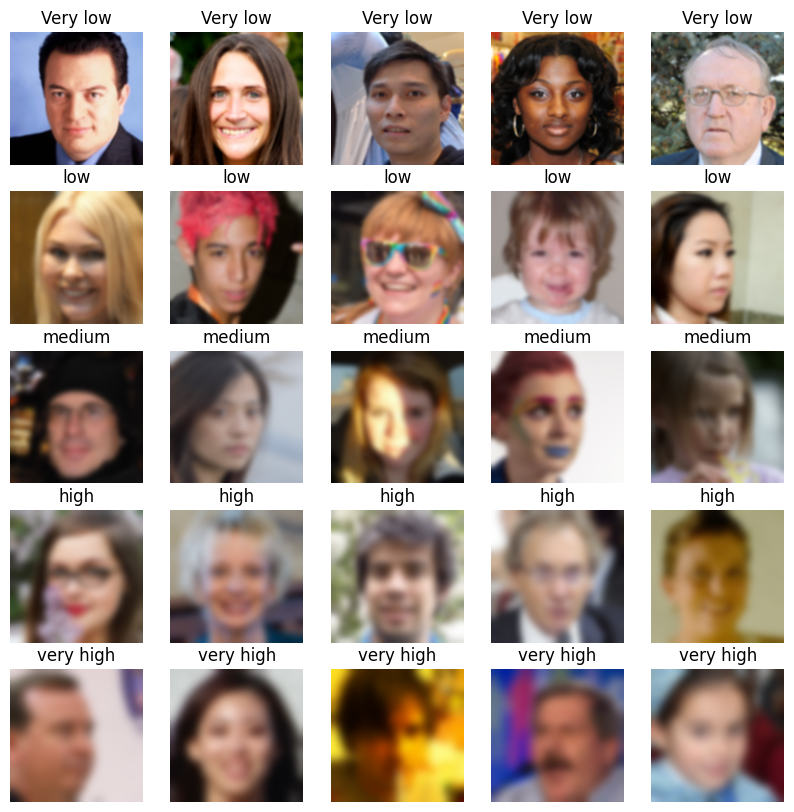

In [19]:
import glob

with tf.device("/device:CPU:0"):

    labels = ["Very low", "low", "medium", "high", "very high"]

    sample_paths = [
        glob.glob(os.path.join(train_dir, "very_low", "*"))[:10],
        glob.glob(os.path.join(train_dir, "low", "*"))[:10],
        glob.glob(os.path.join(train_dir, "medium", "*"))[:10],
        glob.glob(os.path.join(train_dir, "high", "*"))[:10],
        glob.glob(os.path.join(train_dir, "very_high", "*"))[:10],
    ]
    display_images(
        [*sample_paths],
        figsize=(10, 10),
        labels=labels,
        num_samples=5,
        is_preprocessed=False,
    )

## **Modelling**

### **Model Architecture**

In [20]:
with tf.device("/device:CPU:0"):
    inputs = tf.keras.layers.Input(shape=(128, 128, 3))
    x = tf.keras.layers.Conv2D(32, (3, 3), activation="relu")(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(64, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(128, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(256, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D(2, 2)(x)

    x = tf.keras.layers.Conv2D(256, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Conv2D(512, (3, 3), activation="relu")(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(512, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    x = tf.keras.layers.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=x)

    learning_rate = 0.001
    optimizer = tf.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )

In [21]:
with tf.device("/device:CPU:0"):
    parent_dir = rf"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\facial_blur_classification\experiments\blur_severity_level\{blur_type}_experiments_gridSearch"
    model_name = f"{blur_type}_CNN"
    checkpoint, checkpoint_path = checkpoint_callback(model_name, parent_dir)
    early_stopping = early_stopping_callback(patience=20)
    log_dir, tensorboard = tensorboard_callback(parent_dir, model_name)

### **Training Model**

In [ ]:
import time

epochs = 100
batch_size = 8
start_time = time.time()
history = model.fit(
    train_generator,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=validation_generator,
    callbacks=[checkpoint, early_stopping, tensorboard],
)
end_time = time.time()

execution_time = end_time - start_time

### **Plot the Loss, and Accuracy**

In [ ]:
# Plot Training Loss and Validation Loss
plt.figure(figsize=(18, 6))
plt.subplot(121)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss and Validation Loss")
plt.grid(True)

# Plot Training Accuracy and Validation Accuracy
plt.subplot(122)
plt.plot(history.history["accuracy"], label="Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training Accuracy and Validation Accuracy")
plt.grid(True)

plt.tight_layout()
plt.show()

## **Model Evaluation**

In [14]:
model = load_model(
    rf"D:\KLASIFIKASI BERGANDA UNTUK OPTIMASI IMAGE DEBLURRING PADA CITRA DENGAN BLUR YANG BERVARIASI\facial_blur_classification\experiments\blur_severity_level\gaussian_blur_experiments\models\gaussian_blur_CNN.h5"
)

In [ ]:
with tf.device("/device:CPU:0"):
    loss, accuracy = model.evaluate(test_generator)

In [ ]:
print("Evaluation Results:")
print(f"Loss: {loss}")
print(f"Accuracy: {accuracy}")

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Initialize lists to store all the true labels and predictions
all_true_labels = []
all_pred_labels = []

# Loop over the entire test dataset
for batch_images, batch_labels in test_generator:
    # Make predictions for the current batch
    predictions = model.predict(batch_images)
    pred_labels = np.argmax(predictions, axis=1)

    # Append true labels and predicted labels to the lists
    all_true_labels.extend(np.argmax(batch_labels, axis=1))
    all_pred_labels.extend(pred_labels)

    # Check if we've processed the entire dataset (optional step for batching efficiency)
    if len(all_true_labels) >= test_generator.samples:
        break

# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Generate classification report
report = classification_report(
    all_true_labels,
    all_pred_labels,
    target_names=class_labels,
    output_dict=True,
)


In [ ]:
# Convert classification report to DataFrame and round to 3 decimal places
df_report = pd.DataFrame(report).transpose().round(3)

# Optionally, print or return the DataFrame
df_report

In [19]:
class_labels=['high', 'low', 'medium', 'very high', 'very low']

In [ ]:
# Generate the confusion matrix
cm = confusion_matrix(all_true_labels, all_pred_labels)

# Plot confusion matrix using Seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

### **Experiment Logs**

In [ ]:
with tf.device("/device:CPU:0"):
    model_summary_text = []
    for layer in model.layers:
        layer_summary = (
            f"{layer.name} ({layer.__class__.__name__}) {layer.output_shape}"
        )
        model_summary_text.append(layer_summary)

    model_summary_text = "<br/>".join(model_summary_text)
    experiment_notes = create_experiment_notes(
        model_name=model_name,
        model=model_summary_text,
        optimizer=optimizer.__class__.__name__,
        epochs=epochs,
        batch_size=batch_size,
        loss=loss,
        accuracy=accuracy,
        execution_time=execution_time,
    )

    text_file_writer = tf.summary.create_file_writer(log_dir + "/text/")
    with text_file_writer.as_default():
        tf.summary.text(log_dir, experiment_notes, step=0)

In [ ]:
# Initialize variables for collecting sample images and labels
sample_images = []
sample_labels = []

# Number of samples to visualize
num_samples_to_visualize = 10

# Collect sample images and labels from the test generator
num_batches = (
    num_samples_to_visualize + test_generator.batch_size - 1
) // test_generator.batch_size
for _ in range(num_batches):
    batch_images, batch_labels = next(test_generator)
    sample_images.extend(batch_images)
    sample_labels.extend(batch_labels)

# Trim excess images
sample_images = sample_images[:num_samples_to_visualize]
sample_labels = sample_labels[:num_samples_to_visualize]

# Make predictions on the sample images
predictions = model.predict(np.array(sample_images))

# Get class labels from the generator
class_labels = list(test_generator.class_indices.keys())

# Plot the sample images with actual and predicted classes
plt.figure(figsize=(20, 8))
for i in range(num_samples_to_visualize):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])
    actual_class = class_labels[np.argmax(sample_labels[i])]
    predicted_class = class_labels[np.argmax(predictions[i])]
    plt.title(f"Actual: {actual_class}\nPredicted: {predicted_class}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# from utils import shutdown

# shutdown(1)